### Imports e iniciando cessão com o S3

In [21]:
import pandas as pd 
import boto3 
import numpy as np

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *
from src.data.plot import *


load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [3]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- analise_municipio (705.43 KB)
- analise_uf (20.16 KB)
- dim_contexto_socioeconomico_uf (7.79 KB)
- fact_escola (3827.88 KB)
- fact_municipio (100.49 KB)
- fact_uf_ano (25.09 KB)
- ranking_prioridade (966.98 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [4]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")

df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")

for nome, df in {
    "resultado_metas": resultado_metas,
    "resultado_metas_muni": resultado_metas_muni,
    "df_alunos": df_alunos,
    "df_municipios": df_municipios,
    "df_estados": df_estados,
    "df_meta": df_meta,
    "df_alfabetizacao": df_alfabetizacao,
}.items():
    print(f"{nome:22s} -> {df.shape[0]:>10,} linhas x {df.shape[1]:>3} colunas")


Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet
resultado_metas        ->         84 linhas x  19 colunas
resultado_metas_muni   ->     16,286 linhas x  20 colunas
df_alunos              ->  6,090,791 linhas x  11 colunas
df_municipios          ->     36,411 linhas x  20 colunas
df_estados             ->        225 linhas x  18 colunas
df_meta                -> 11,589,070 l

## <font color="green">Enriquecendo a tabela dos Alunos </font>

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [5]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [8]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


✅ Merge concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO: 3929
Percentual de nulos: 0.06%


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [10]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
    on=['NU_ANO_AVALIACAO', 'CO_UF'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


✅ Merge de Estado concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_UF: 27698
Percentual de nulos: 0.45%


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [11]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [12]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 21


In [13]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

In [14]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'ID_ALUNO', 'ID_ESCOLA',
       'TP_DEPENDENCIA', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP',
       'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO',
       'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
       'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
       'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024',
       'META_UF_2025', 'META_UF_2026'],
      dtype='str')

In [17]:
colunas = [
    'NU_ANO_AVALIACAO', 'CO_UF',
    'TP_DEPENDENCIA',
    'CO_MUNICIPIO',
    'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP', 'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP',
    'IN_ALFABETIZADO',
    'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
    'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
    'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026',
    'META_UF_2024', 'META_UF_2025', 'META_UF_2026',
]

# Segurança: mantém só o que realmente existe em df_alunos (evita KeyError se o schema mudar)
colunas_faltantes = [c for c in colunas if c not in df_alunos.columns]
colunas = [c for c in colunas if c in df_alunos.columns]

if colunas_faltantes:
    print("⚠️ Colunas não encontradas em df_alunos (ignoradas):", colunas_faltantes)

alunos = df_alunos[colunas].copy()
print(f"\n'alunos' selecionado com {len(colunas)} colunas e {len(alunos):,} linhas.")



'alunos' selecionado com 19 colunas e 6,090,791 linhas.


In [18]:
print('percentual de nulo na base')
(alunos.isna().mean() * 100).round(2)

percentual de nulo na base


NU_ANO_AVALIACAO                          0.00
CO_UF                                     0.00
TP_DEPENDENCIA                            0.01
CO_MUNICIPIO                              0.01
IN_PRESENCA_LP                            0.00
IN_PREENCHIMENTO_LP                       0.00
VL_PESO_ALUNO_LP                         12.63
VL_PROFICIENCIA_LP                       12.63
IN_ALFABETIZADO                           0.00
VL_MEDIA_LP_TOTAL_MUNICIPIO               0.06
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO     0.06
VL_MEDIA_LP_TOTAL_UF                      0.45
PC_ALUNO_ALFABETIZADO_TOTAL_UF            0.45
META_MUN_2024                             3.73
META_MUN_2025                             3.18
META_MUN_2026                             2.74
META_UF_2024                              6.00
META_UF_2025                              4.67
META_UF_2026                              4.67
dtype: float64

### 2.1 Situação da avaliação — ausentes e preenchimento inválido

> **Revisão de decisão (ponto levantado):** inicialmente a ideia era *excluir* alunos ausentes ou
> com preenchimento inválido da base de modelagem. Reconsiderando: esses alunos **não são um dado
> ausente qualquer** — são, com grande probabilidade, o público de **maior risco educacional**
> (evasão, baixa frequência, vulnerabilidade), exatamente o grupo que o Tech Challenge pede para
> identificar ("municípios/alunos de maior risco educacional"). Excluí-los enviesaria o modelo para
> o público "mais fácil" (quem compareceu e conseguiu preencher a prova).
>
> A metodologia oficial do Compromisso Nacional Criança Alfabetizada, inclusive, trata alunos não
> avaliados como **não alfabetizados** para fins do indicador — pois a rede não conseguiu comprovar
> a alfabetização deles. Vamos seguir essa mesma lógica aqui, mas de forma transparente e testável.


In [19]:
print("Distribuição de IN_PRESENCA_LP:")
print(alunos['IN_PRESENCA_LP'].value_counts(dropna=False), "\n")

print("Distribuição de IN_PREENCHIMENTO_LP:")
print(alunos['IN_PREENCHIMENTO_LP'].value_counts(dropna=False))


Distribuição de IN_PRESENCA_LP:
IN_PRESENCA_LP
1    5325767
0     765024
Name: count, dtype: int64 

Distribuição de IN_PREENCHIMENTO_LP:
IN_PREENCHIMENTO_LP
1    5321266
0     769525
Name: count, dtype: int64


In [22]:
# Classificação vetorizada da situação da avaliação (não removemos nenhuma linha)
condicoes = [
    (alunos['IN_PRESENCA_LP'] == 1) & (alunos['IN_PREENCHIMENTO_LP'] == 1),
    (alunos['IN_PRESENCA_LP'] != 1),
]
valores = ['Avaliado - válido', 'Ausente']
alunos['SITUACAO_AVALIACAO'] = np.select(condicoes, valores, default='Avaliado - preenchimento inválido')

print(alunos['SITUACAO_AVALIACAO'].value_counts(dropna=False))
print()
print((alunos['SITUACAO_AVALIACAO'].value_counts(normalize=True) * 100).round(2))


SITUACAO_AVALIACAO
Avaliado - válido                    5321266
Ausente                               765024
Avaliado - preenchimento inválido       4501
Name: count, dtype: int64

SITUACAO_AVALIACAO
Avaliado - válido                    87.37
Ausente                              12.56
Avaliado - preenchimento inválido     0.07
Name: proportion, dtype: float64


#### Testando a hipótese: ausência/invalidação está concentrada em áreas de maior risco?

Se a taxa de ausência/invalidação for sistematicamente maior em certas UFs, redes ou municípios
(em vez de aleatória), isso reforça que **não é um dado faltante ao acaso** — é sinal de risco.


C:\Users\jack_\AppData\Local\Temp\ipykernel_19184\827679375.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_por_uf.index, y=taxa_por_uf.values, palette='rocket')


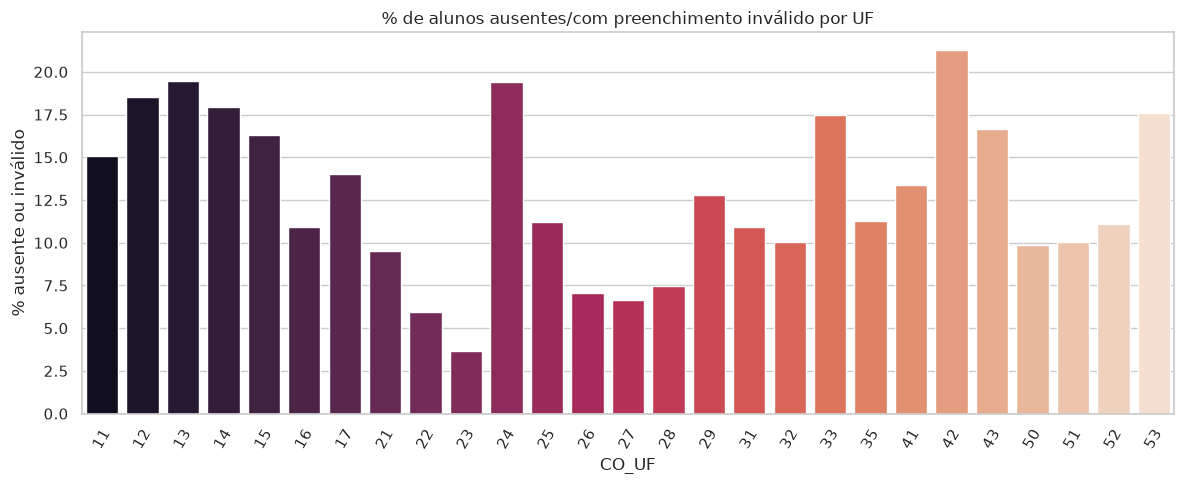

Amplitude entre UFs: 21.3% (pior) vs 3.7% (melhor)
Se a amplitude for grande, a ausência NÃO é aleatória — é um sinal de risco territorial.


In [27]:
alunos['FL_NAO_AVALIADO_VALIDO'] = (alunos['SITUACAO_AVALIACAO'] != 'Avaliado - válido').astype(int)

taxa_por_uf = (
    alunos.groupby('CO_UF')['FL_NAO_AVALIADO_VALIDO']
    .mean().mul(100).sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=taxa_por_uf.index, y=taxa_por_uf.values, palette='rocket')
plt.title('% de alunos ausentes/com preenchimento inválido por UF')
plt.ylabel('% ausente ou inválido')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print(f"Amplitude entre UFs: {taxa_por_uf.max():.1f}% (pior) vs {taxa_por_uf.min():.1f}% (melhor)")
print("Se a amplitude for grande, a ausência NÃO é aleatória — é um sinal de risco territorial.")


In [28]:
if 'DESC_DEPENDENCIA' in alunos.columns:
    taxa_por_rede = (
        alunos.groupby('DESC_DEPENDENCIA')['FL_NAO_AVALIADO_VALIDO']
        .mean().mul(100).sort_values(ascending=False)
    )
    display(taxa_por_rede)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=taxa_por_rede.index, y=taxa_por_rede.values, palette='rocket')
    plt.title('% de ausência/invalidação por rede de ensino')
    plt.ylabel('% ausente ou inválido')
    plt.show()


In [30]:
# Top 15 municípios com maior taxa de ausência/invalidação (candidatos a alerta de risco)
top_municipios_ausencia = (
    alunos.groupby(['CO_UF', 'CO_MUNICIPIO'])
    .agg(
        taxa_ausencia=('FL_NAO_AVALIADO_VALIDO', 'mean'),
        qtd_alunos=('FL_NAO_AVALIADO_VALIDO', 'size'),
    )
    .query('qtd_alunos >= 30')  # remove municípios com poucos alunos (taxa instável)
    .assign(taxa_ausencia=lambda d: (d['taxa_ausencia'] * 100).round(2))
    .sort_values('taxa_ausencia', ascending=False)
    .reset_index()
)

top_municipios_ausencia.head(15)


,CO_UF,CO_MUNICIPIO,taxa_ausencia,qtd_alunos
0,31,3162450.0,62.21,516
1,52,5219308.0,53.26,860
2,42,4207684.0,51.70,470
3,13,1301100.0,49.44,1594
4,42,4203204.0,48.67,5032
5,42,4202008.0,48.01,3978
6,31,3106606.0,40.61,197
7,42,4218004.0,40.45,2282
8,41,4128625.0,38.93,131
9,43,4306767.0,37.82,1465


#### Redefinindo o target de forma transparente

Duas versões do target ficam disponíveis, lado a lado, para permitir análise de sensibilidade:

- **`IN_ALFABETIZADO_ESTRITO`** — mantém `NaN` para quem não tem avaliação válida (visão conservadora,
  "não sabemos").
- **`IN_ALFABETIZADO_FINAL`** *(recomendado, usado no restante do notebook)* — ausente/preenchimento
  inválido é tratado como **não alfabetizado (0)**, alinhado à metodologia oficial e à hipótese de que
  esse grupo representa risco educacional real.

> ⚠️ Isso é uma decisão de modelagem com impacto direto nos resultados — documentar essa escolha no
> README é obrigatório (vai mudar o balanceamento de classes e as métricas).


In [31]:
alunos['IN_ALFABETIZADO_ESTRITO'] = np.where(
    alunos['SITUACAO_AVALIACAO'] == 'Avaliado - válido', alunos['IN_ALFABETIZADO'], np.nan
)

alunos['IN_ALFABETIZADO_FINAL'] = np.where(
    alunos['SITUACAO_AVALIACAO'] == 'Avaliado - válido', alunos['IN_ALFABETIZADO'], 0
)

comparacao_targets = pd.DataFrame({
    '% ESTRITO (só avaliados válidos)': alunos['IN_ALFABETIZADO_ESTRITO'].value_counts(normalize=True).mul(100).round(2),
    '% FINAL (ausente/inválido = 0, recomendado)': alunos['IN_ALFABETIZADO_FINAL'].value_counts(normalize=True).mul(100).round(2),
})
comparacao_targets


,% ESTRITO (só avaliados válidos),"% FINAL (ausente/inválido = 0, recomendado)"
1.0,61.78,53.98
0.0,38.22,46.02


In [32]:
# A partir daqui, `alunos_validos` = base COMPLETA (nenhuma linha removida), com o target
# recomendado (`IN_ALFABETIZADO_FINAL`) já aplicado em `IN_ALFABETIZADO`, para manter compatibilidade
# com o restante do notebook.
alunos_validos = alunos.copy()
alunos_validos['IN_ALFABETIZADO'] = alunos_validos['IN_ALFABETIZADO_FINAL']

print(f"Linhas em alunos_validos: {len(alunos_validos):,} (nenhuma removida)")
print(f"Novo balanceamento do target 'IN_ALFABETIZADO':")
print(alunos_validos['IN_ALFABETIZADO'].value_counts(normalize=True).mul(100).round(2))


Linhas em alunos_validos: 6,090,791 (nenhuma removida)
Novo balanceamento do target 'IN_ALFABETIZADO':
IN_ALFABETIZADO
1    53.98
0    46.02
Name: proportion, dtype: float64


### 2.2 Otimização de memória

Redução de footprint antes de trabalhar com a base inteira (6M+ linhas): `category` para
colunas de baixa cardinalidade e downcast de numéricos.


In [33]:
def otimizar_memoria(df: pd.DataFrame, cols_categoricas: list[str] | None = None) -> pd.DataFrame:
    """Reduz uso de memória: category para colunas de baixa cardinalidade,
    downcast para inteiros/floats."""
    df = df.copy()
    cols_categoricas = cols_categoricas or []

    for col in cols_categoricas:
        if col in df.columns:
            df[col] = df[col].astype('category')

    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    return df


mem_antes = alunos_validos.memory_usage(deep=True).sum() / 1024**2

cols_baixa_cardinalidade = [
    'CO_UF', 'SG_UF', 'TP_DEPENDENCIA', 'DESC_DEPENDENCIA', 'TP_SERIE', 'DESC_SERIE',
]
cols_baixa_cardinalidade = [c for c in cols_baixa_cardinalidade if c in alunos_validos.columns]

alunos_validos = otimizar_memoria(alunos_validos, cols_baixa_cardinalidade)

mem_depois = alunos_validos.memory_usage(deep=True).sum() / 1024**2
print(f"Memória antes : {mem_antes:,.2f} MB")
print(f"Memória depois: {mem_depois:,.2f} MB  ({(1 - mem_depois / mem_antes):.1%} de redução)")


Memória antes : 1,165.39 MB
Memória depois: 520.63 MB  (55.3% de redução)


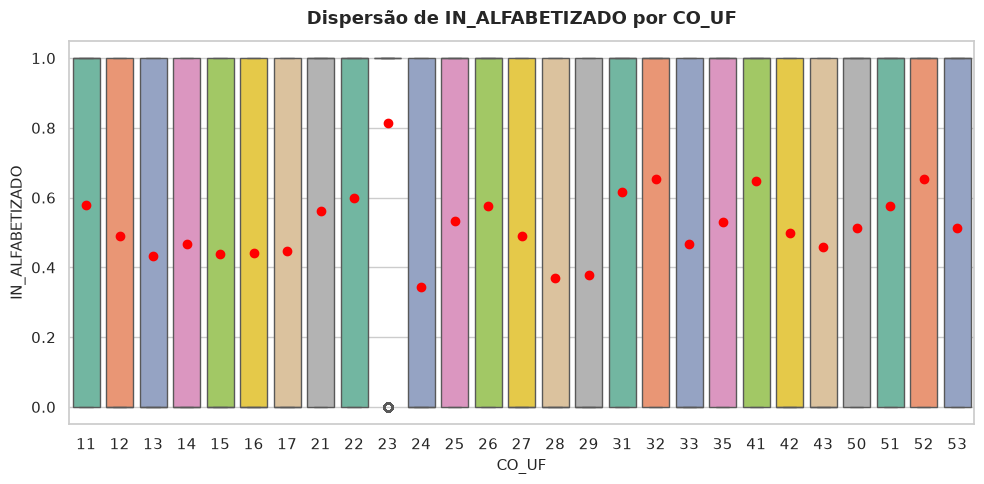

In [35]:
gerar_boxplot(df = alunos, x = 'CO_UF', y="IN_ALFABETIZADO",salvar=False )

📊 Gráfico salvo em: C:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\reports\figures\kde_IN_ALFABETIZADO_por_TP_DEPENDENCIA.png


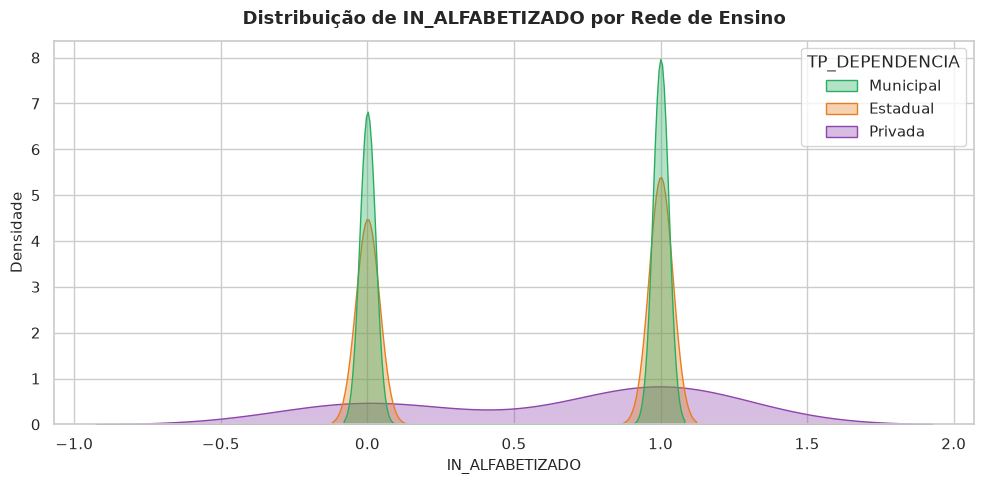

In [36]:
gerar_kdeplot(alunos,x='IN_ALFABETIZADO')

📊 Gráfico salvo em: C:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\reports\figures\bar_media_IN_ALFABETIZADO_por_CO_UF.png


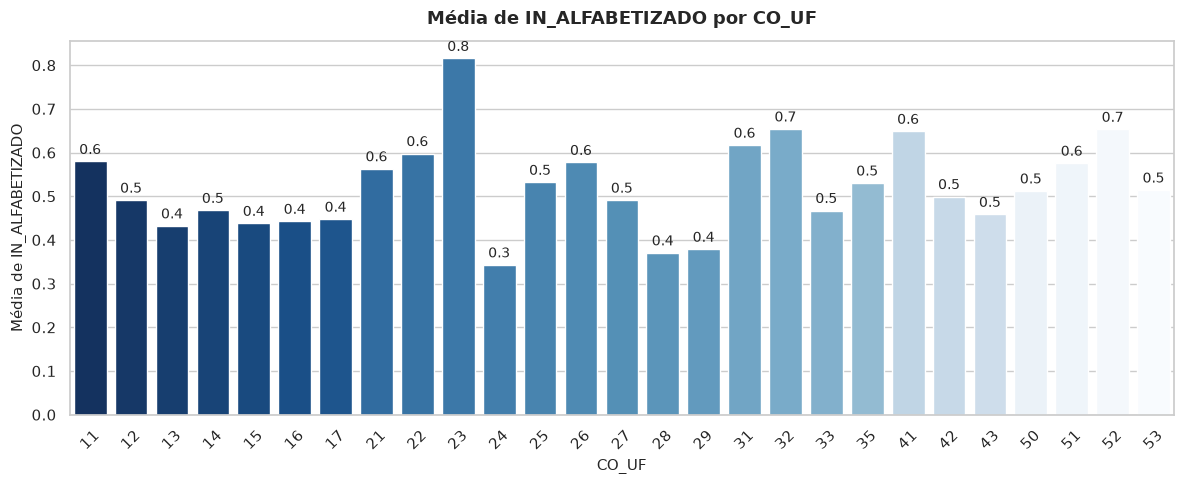

In [37]:
gerar_barplot_medias(alunos,x='CO_UF',y='IN_ALFABETIZADO')

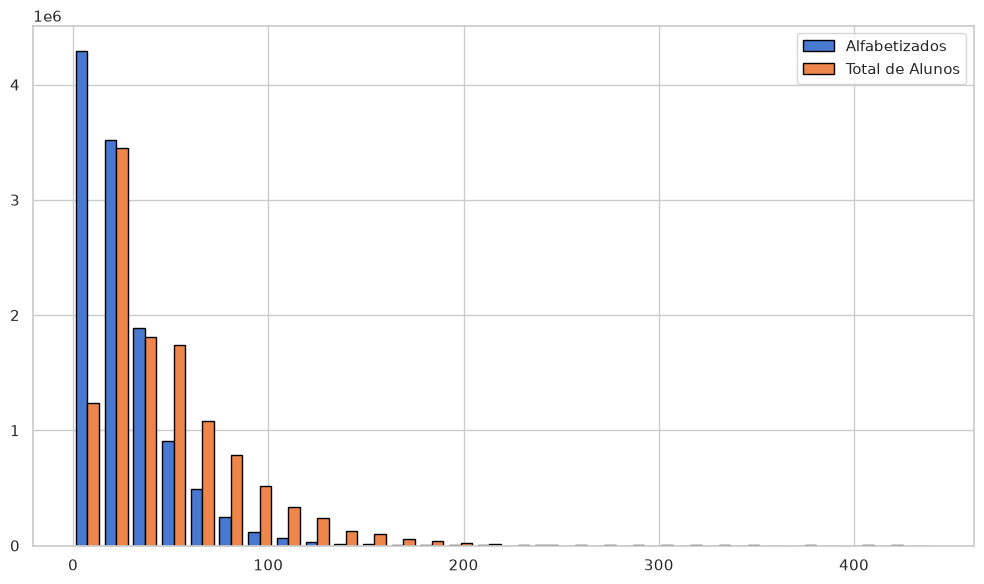

In [38]:
# Alternativa puramente com Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(
    [df_meta['QT_ALFABETIZADOS'], df_meta['QT_ALUNOS']], 
    bins=30, 
    label=['Alfabetizados', 'Total de Alunos'],
    edgecolor='black'
)

plt.legend()
plt.show()


In [39]:
tabelas = ['RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS','TS_ALUNO','TS_ESTADO','TS_ITEM','TS_MUNICIPIO' ] 
pastas = ['dimensao','historico','fato'] 


df = carregar_parquet_s3(
    s3_client=s3,
    bucket=BUCKET,
    ano= pastas[0],
    nome_tabela=tabelas[0],
    camada="gold"
)


Lendo: s3://postech-challenge-datascience-003/gold/ano=dimensao/dados/RESULTADOS_METAS_MUNICIPIO.parquet


---
# <font color="green">Cruzamentos e Análises — Tech Challenge 3</font>

A partir daqui o notebook carrega as bases de **contexto externo** (`gold/dados_externos`) e realiza os
principais cruzamentos entre desempenho de alfabetização, rede de ensino, metas e contexto
socioeconômico.

## 1. Carga das bases de contexto externo (`gold/dados_externos`)

In [41]:
prefixo_externo = "dados_externos"

df_contexto_uf    = carregar_parquet_s3(s3, BUCKET, "dim_contexto_socioeconomico_uf", subpasta=prefixo_externo)
#df_fact_uf_ano    = carregar_parquet_s3(s3, BUCKET, "fact_uf_ano", subpasta=prefixo_externo)
df_fact_municipio = carregar_parquet_s3(s3, BUCKET, "fact_municipio", subpasta=prefixo_externo)
# fact_escola é a maior base (~19 MB); carregue só se for analisar no nível de escola
df_fact_escola    = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta=prefixo_externo)

bases_externas = {
    "df_contexto_uf": df_contexto_uf,
    "df_fact_uf_ano": df_fact_uf_ano,
    "df_fact_municipio": df_fact_municipio,
    "df_fact_escola": df_fact_escola,
}

for nome, df in bases_externas.items():
    print(f"\n=== {nome} — shape: {df.shape} ===")
    print("Colunas:", list(df.columns))
    display(df.head(3))


Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet

=== df_contexto_uf — shape: (81, 7) ===
Colunas: ['ANO', 'COD_UF', 'POPULACAO_MIL', 'TAXA_ANALFABETISMO_PCT', 'RENDIMENTO_MEDIO_MENSAL_REAIS', 'RENDA_PERCAPITA_SBENEF_MEDIO', 'TAXA_FREQ_LIQUIDA_FUND_PCT']


,ANO,COD_UF,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT
0,2023,11.0,94,5.1,2916,1524.801152,89.593066
1,2023,12.0,59,9.6,2599,1004.112711,88.407203
2,2023,13.0,296,5.0,2549,1111.498981,92.050449



=== df_fact_uf_ano — shape: (81, 32) ===
Colunas: ['ANO', 'COD_REGIAO', 'NO_REGIAO', 'COD_UF', 'SG_UF', 'UNIDGEO', 'ED_INF_CAT_0', 'CRE_CAT_0', 'PRE_CAT_0', 'FUN_CAT_0', 'FUN_AI_CAT_0', 'FUN_AF_CAT_0', 'FUN_01_CAT_0', 'FUN_02_CAT_0', 'FUN_03_CAT_0', 'FUN_04_CAT_0', 'FUN_05_CAT_0', 'FUN_06_CAT_0', 'FUN_07_CAT_0', 'FUN_08_CAT_0', 'FUN_09_CAT_0', 'MED_CAT_0', 'MED_01_CAT_0', 'MED_02_CAT_0', 'MED_03_CAT_0', 'MED_04_CAT_0', 'MED_NS_CAT_0', 'POPULACAO_MIL', 'TAXA_ANALFABETISMO_PCT', 'RENDIMENTO_MEDIO_MENSAL_REAIS', 'RENDA_PERCAPITA_SBENEF_MEDIO', 'TAXA_FREQ_LIQUIDA_FUND_PCT']


,ANO,COD_REGIAO,NO_REGIAO,COD_UF,SG_UF,UNIDGEO,ED_INF_CAT_0,CRE_CAT_0,PRE_CAT_0,FUN_CAT_0,...,MED_01_CAT_0,MED_02_CAT_0,MED_03_CAT_0,MED_04_CAT_0,MED_NS_CAT_0,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT
0,2023,1.0,Norte,11.0,RO,Rondônia,4.5,5.3,4.1,4.3,...,5.7,5.7,5.1,12.4,4.1,94,5.1,2916,1524.801152,NaN
1,2023,1.0,Norte,12.0,AC,Acre,4.8,5.8,4.4,4.6,...,5.8,5.4,5.3,NaN,4.4,59,9.6,2599,1004.112711,NaN
2,2023,1.0,Norte,13.0,AM,Amazonas,4.4,4.9,4.2,4.6,...,5.0,5.3,4.9,NaN,3.7,296,5.0,2549,1111.498981,NaN



=== df_fact_municipio — shape: (16711, 14) ===
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'FUN_02_CAT_0', 'COD_RISCO_UF', 'CATEGORIA_RISCO_UF', 'COD_RISCO_MUNICIPIO', 'CATEGORIA_RISCO_MUNICIPIO', 'NIVEL_RISCO_DESC_MUNICIPIO', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']


,ANO,COD_UF,CO_MUNICIPIO,FUN_02_CAT_0,COD_RISCO_UF,CATEGORIA_RISCO_UF,COD_RISCO_MUNICIPIO,CATEGORIA_RISCO_MUNICIPIO,NIVEL_RISCO_DESC_MUNICIPIO,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
0,2023.0,11,1100015.0,4.3,5.0,Muito alto,2.0,Baixo,2 – Risco moderado-baixo de não alcançar a meta,94,5.1,2916,1524.801152,89.593066
1,2023.0,11,1100023.0,4.3,5.0,Muito alto,1.0,Muito baixo,1 – Baixo risco de não alcançar a meta,94,5.1,2916,1524.801152,89.593066
2,2023.0,11,1100031.0,4.0,5.0,Muito alto,5.0,Muito alto,5 – Alto risco de não alcançar a meta,94,5.1,2916,1524.801152,89.593066



=== df_fact_escola — shape: (517080, 15) ===
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'CO_ENTIDADE', 'FUN_02_CAT_0', 'COD_RISCO_ESCOLA', 'CATEGORIA_RISCO_ESCOLA', 'NIVEL_RISCO_DESC_ESCOLA', 'DESC_IMPACTO_ESCOLA', 'QT_MATRICULA_2ANO_EF', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']


,ANO,COD_UF,CO_MUNICIPIO,CO_ENTIDADE,FUN_02_CAT_0,COD_RISCO_ESCOLA,CATEGORIA_RISCO_ESCOLA,NIVEL_RISCO_DESC_ESCOLA,DESC_IMPACTO_ESCOLA,QT_MATRICULA_2ANO_EF,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
0,2023.0,11,1100015.0,11022558.0,NaN,NaN,NaN,NaN,NaN,NaN,94,5.1,2916,1524.801152,89.593066
1,2023.0,11,1100015.0,11024372.0,4.3,NaN,NaN,NaN,NaN,NaN,94,5.1,2916,1524.801152,89.593066
2,2023.0,11,1100015.0,11024666.0,4.3,4.0,Alto,4 – Risco moderado-alto de não alcançar a meta,Muitos estudantes impactados,15.0,94,5.1,2916,1524.801152,89.593066


### 1.1 Identificando as chaves de junção

Detecta automaticamente colunas candidatas a chave (`CO_UF`, `CD_UF`, `SG_UF`, `CO_MUNICIPIO`) em cada
base externa, para usar nos merges das próximas seções.


In [42]:
# Schema confirmado a partir da inspeção direta dos arquivos parquet (não é mais um "chute"):
#
# dim_contexto_socioeconomico_uf: chave = ['ANO', 'COD_UF']  (93 linhas, 2023-2025)
# fact_municipio                : chave = ['ANO', 'COD_UF', 'CO_MUNICIPIO']  (tem linhas duplicadas -> dedup!)
#                                  também traz CATEGORIA_RISCO_MUNICIPIO e CATEGORIA_RISCO_UF
#                                  (classificação oficial de risco de não atingir a meta)
# fact_escola                   : traz COD_UF e CO_MUNICIPIO próprios (não usaremos CO_ENTIDADE/ID_ESCOLA
#                                  para juntar aluno-a-aluno — ver observação abaixo)
#
# Observação: COD_UF usa a mesma codificação numérica do IBGE que CO_UF em `alunos` (11=RO, 12=AC...).
# DEPENDENCIA_ADM é string ('Municipal'/'Estadual'/'Privada'/'Federal') — mesmo domínio de
# DESC_DEPENDENCIA em `alunos`.
#
# ⚠️ Chave de município: usamos CO_UF + CO_MUNICIPIO (chave composta), não CO_MUNICIPIO isolado.
# Mesmo o código IBGE de 7 dígitos já embutindo a UF, fontes diferentes às vezes truncam para 6
# dígitos ou formatam de forma inconsistente — a chave composta evita colisão silenciosa entre
# municípios de UFs diferentes e serve de checagem de consistência (CO_UF do aluno deve bater com
# CO_UF do município).
#
# ⚠️ ID_ESCOLA (aluno) x CO_ENTIDADE (fact_escola): NÃO vamos usar essa chave. ID_ESCOLA em df_alunos
# é uma máscara/hash aplicada por questões de privacidade e não corresponde ao código INEP real
# (CO_ENTIDADE) — não há como casar aluno-a-aluno com a escola de origem. A solução é agregar
# fact_escola ao nível de MUNICÍPIO (que ele já traz nativamente via COD_UF/CO_MUNICIPIO) e usar
# como feature municipal — ver Seção 4.6 revisada.

def preparar_chave_uf(df, col_cod_uf='COD_UF', col_ano='ANO'):
    out = df.copy()
    out['CO_UF'] = pd.to_numeric(out[col_cod_uf], errors='coerce').astype('Int64')
    if col_ano in out.columns:
        out['NU_ANO_AVALIACAO'] = pd.to_numeric(out[col_ano], errors='coerce').astype('Int64')
    return out

def preparar_chave_municipio(df, col_cod_uf='COD_UF', col_cod_muni='CO_MUNICIPIO', col_ano='ANO'):
    out = df.copy()
    out['CO_UF'] = pd.to_numeric(out[col_cod_uf], errors='coerce').astype('Int64')
    out['CO_MUNICIPIO'] = pd.to_numeric(out[col_cod_muni], errors='coerce').astype('Int64')
    if col_ano in out.columns:
        out['NU_ANO_AVALIACAO'] = pd.to_numeric(out[col_ano], errors='coerce').astype('Int64')
    return out


df_contexto_uf    = preparar_chave_uf(df_contexto_uf)
df_fact_municipio = preparar_chave_municipio(df_fact_municipio)
df_fact_escola     = preparar_chave_municipio(df_fact_escola)  # idem: precisamos de CO_UF+CO_MUNICIPIO para agregar

# Anos disponíveis nas bases externas — confirme que há sobreposição com NU_ANO_AVALIACAO de `alunos`
print("Anos em df_contexto_uf   :", sorted(df_contexto_uf['NU_ANO_AVALIACAO'].dropna().unique().tolist()))
print("Anos em df_fact_municipio:", sorted(df_fact_municipio['NU_ANO_AVALIACAO'].dropna().unique().tolist()))
print("Anos em df_fact_escola   :", sorted(df_fact_escola['NU_ANO_AVALIACAO'].dropna().unique().tolist()))
print("Anos em alunos           :", sorted(pd.to_numeric(alunos['NU_ANO_AVALIACAO'], errors='coerce').dropna().unique().tolist()))

# Checagem de consistência: CO_UF do aluno bate com o CO_UF do município nas bases externas?
municipios_com_uf = df_fact_municipio[['CO_UF', 'CO_MUNICIPIO']].drop_duplicates()
print(f"\nMunicípios únicos em fact_municipio: {len(municipios_com_uf)}")
print(f"Combinações CO_UF+CO_MUNICIPIO duplicadas com UF divergente: "
      f"{municipios_com_uf['CO_MUNICIPIO'].duplicated().sum()} "
      f"(se > 0, há municípios com o mesmo código associados a UFs diferentes — investigar)")


Anos em df_contexto_uf   : [2023, 2024, 2025]
Anos em df_fact_municipio: [2023, 2024, 2025]
Anos em df_fact_escola   : [2023, 2024, 2025]
Anos em alunos           : [2023, 2024, 2025]

Municípios únicos em fact_municipio: 5571
Combinações CO_UF+CO_MUNICIPIO duplicadas com UF divergente: 0 (se > 0, há municípios com o mesmo código associados a UFs diferentes — investigar)


## 2. Cruzamento 1 — Contexto socioeconômico (UF) × Alfabetização

In [43]:
# Indicadores de alfabetização por UF E ANO (o contexto socioeconômico varia ano a ano)
indicadores_uf = (
    alunos_validos
    .groupby(['CO_UF', 'NU_ANO_AVALIACAO'])
    .agg(
        pct_alfabetizados=('IN_ALFABETIZADO', 'mean'),
        proficiencia_media=('VL_PROFICIENCIA_LP', 'mean'),
        qtd_alunos=('IN_ALFABETIZADO', 'size'),
    )
    .reset_index()
)
indicadores_uf['pct_alfabetizados'] *= 100
indicadores_uf['CO_UF'] = indicadores_uf['CO_UF'].astype('Int64')
indicadores_uf['NU_ANO_AVALIACAO'] = pd.to_numeric(indicadores_uf['NU_ANO_AVALIACAO'], errors='coerce').astype('Int64')

# dim_contexto_socioeconomico_uf tem linhas duplicadas para a mesma chave -> deduplicar antes do merge
contexto_uf_dedup = df_contexto_uf.drop_duplicates(subset=['CO_UF', 'NU_ANO_AVALIACAO'])

cruzamento_uf_contexto = indicadores_uf.merge(
    contexto_uf_dedup,
    on=['CO_UF', 'NU_ANO_AVALIACAO'],
    how='left',
)

print(f"Linhas de indicadores_uf: {len(indicadores_uf)} | Após merge: {len(cruzamento_uf_contexto)}")
print(f"Nulos em POPULACAO_MIL após merge: {cruzamento_uf_contexto['POPULACAO_MIL'].isna().sum()} "
      f"({cruzamento_uf_contexto['POPULACAO_MIL'].isna().mean():.1%}) "
      f"— se estiver alto, o ano de alunos não sobrepõe os anos de df_contexto_uf (2023-2025); "
      f"nesse caso, considere usar o contexto do ano mais próximo disponível.")

display(cruzamento_uf_contexto.head())


Linhas de indicadores_uf: 76 | Após merge: 76
Nulos em POPULACAO_MIL após merge: 0 (0.0%) — se estiver alto, o ano de alunos não sobrepõe os anos de df_contexto_uf (2023-2025); nesse caso, considere usar o contexto do ano mais próximo disponível.


,CO_UF,NU_ANO_AVALIACAO,pct_alfabetizados,proficiencia_media,qtd_alunos,ANO,COD_UF,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT
0,11,2023,57.484453,760.215637,22834,2023,11.0,94,5.1,2916,1524.801152,89.593066
1,11,2024,55.665329,745.905029,22673,2024,11.0,99,5.2,3071,1652.756338,90.173058
2,11,2025,60.325087,762.599670,26639,2025,11.0,107,5.1,3336,1791.449009,90.756804
3,12,2024,41.967602,739.687744,12655,2024,12.0,58,9.4,2652,1135.136958,88.738455
4,12,2025,56.180834,753.215271,12741,2025,12.0,63,8.9,2796,1283.258244,89.070948


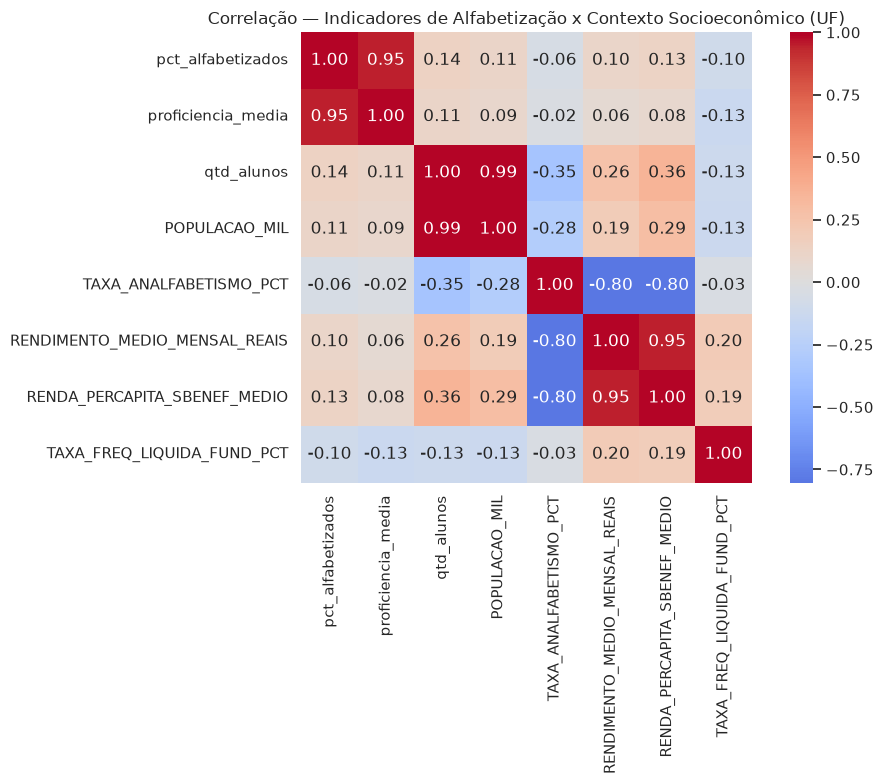

In [50]:
# Correlação entre indicadores educacionais e variáveis de contexto socioeconômico
#
# Excluímos explicitamente identificadores/chaves do cálculo de correlação:
# - CO_UF / COD_UF: é um CÓDIGO categórico (IBGE), não uma grandeza contínua. Correlacioná-lo
#   numericamente produz "relações" espúrias que refletem apenas a ORDEM de numeração das UFs
#   por região (Norte 11-17, Nordeste 21-29, Sudeste 31-35...), não uma relação real.
# - NU_ANO_AVALIACAO / ANO: identificador temporal (e duplicado, vindo de bases diferentes),
#   não uma variável explicativa contínua nesse contexto.
cols_identificadoras = ['CO_UF', 'COD_UF', 'NU_ANO_AVALIACAO', 'ANO']
cols_numericas_cruzamento = [
    c for c in cruzamento_uf_contexto.select_dtypes(include=[np.number]).columns
    if c not in cols_identificadoras
]

if len(cols_numericas_cruzamento) > 2:
    corr_contexto = cruzamento_uf_contexto[cols_numericas_cruzamento].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_contexto, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlação — Indicadores de Alfabetização x Contexto Socioeconômico (UF)")
    plt.tight_layout()
    plt.show()
else:
    print("Poucas colunas numéricas para gerar a matriz de correlação. Confira o merge acima.")


In [45]:
# Foco: correlação de cada variável de contexto com o % de alfabetizados
if 'pct_alfabetizados' in cruzamento_uf_contexto.columns and len(cols_numericas_cruzamento) > 2:
    corr_com_alfabetizacao = (
        cruzamento_uf_contexto[cols_numericas_cruzamento]
        .corr(numeric_only=True)['pct_alfabetizados']
        .drop('pct_alfabetizados')
        .sort_values(key=abs, ascending=False)
    )
    print("Variáveis de contexto mais correlacionadas com % de alfabetizados:\n")
    display(corr_com_alfabetizacao)


Variáveis de contexto mais correlacionadas com % de alfabetizados:



proficiencia_media               0.947107
ANO                              0.366282
NU_ANO_AVALIACAO                 0.366282
CO_UF                            0.186231
COD_UF                           0.186231
qtd_alunos                       0.137363
RENDA_PERCAPITA_SBENEF_MEDIO     0.130957
POPULACAO_MIL                    0.112888
RENDIMENTO_MEDIO_MENSAL_REAIS    0.102649
TAXA_FREQ_LIQUIDA_FUND_PCT      -0.096171
TAXA_ANALFABETISMO_PCT          -0.055708
Name: pct_alfabetizados, dtype: float64

## 3. Cruzamento 2 — Rede de Ensino (`TP_DEPENDENCIA`) × Alfabetização × Meta

In [46]:
cruzamento_rede = (
    alunos
    .groupby(['TP_DEPENDENCIA', 'DESC_DEPENDENCIA'])
    .agg(
        pct_alfabetizados=('IN_ALFABETIZADO', 'mean'),
        proficiencia_media=('VL_PROFICIENCIA_LP', 'mean'),
        qtd_alunos=('IN_ALFABETIZADO', 'size'),
    )
    .reset_index()
    .sort_values('pct_alfabetizados', ascending=False)
)
cruzamento_rede['pct_alfabetizados'] *= 100
cruzamento_rede


KeyError: 'DESC_DEPENDENCIA'

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cruzamento_rede, x='DESC_DEPENDENCIA', y='pct_alfabetizados', palette='viridis')
plt.title('% de alfabetizados por rede de ensino')
plt.ylabel('% alfabetizados')
plt.xlabel('Rede')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


NameError: name 'cruzamento_rede' is not defined

<Figure size 1000x500 with 0 Axes>

## 4. Cruzamento 3 — Realizado × Meta (Município e UF)

In [49]:
# 4.1 Nível Município
metas_mun_cols = [c for c in ['META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in alunos.columns]

gap_municipio = (
    alunos
    .dropna(subset=['PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'])
    .groupby(['CO_UF', 'CO_MUNICIPIO'])
    .agg(
        pct_realizado=('PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'mean'),
        **{m: (m, 'mean') for m in metas_mun_cols}
    )
    .reset_index()
)

for meta_col in metas_mun_cols:
    gap_municipio[f'GAP_{meta_col}'] = gap_municipio['pct_realizado'] - gap_municipio[meta_col]

gap_municipio.describe().T


,count,mean,std,min,25%,50%,75%,max
CO_UF,5567.0,3.237345e+01,9.835556,1.100000e+01,2.500000e+01,3.100000e+01,4.100000e+01,5.300000e+01
CO_MUNICIPIO,5567.0,3.253163e+06,985078.880475,1.100015e+06,2.512089e+06,3.146206e+06,4.119054e+06,5.300108e+06
pct_realizado,5567.0,6.557377e+01,15.714329,1.245213e+01,5.473983e+01,6.645248e+01,7.722276e+01,1.000000e+02
META_MUN_2024,5471.0,6.187972e+01,15.284993,7.958189e+00,5.132490e+01,6.388695e+01,7.585964e+01,8.000000e+01
META_MUN_2025,5476.0,6.520553e+01,12.643344,1.401709e+01,5.697101e+01,6.693962e+01,7.670664e+01,8.000000e+01
META_MUN_2026,5522.0,6.850131e+01,9.861808,2.376512e+01,6.215049e+01,6.988730e+01,7.714111e+01,8.000000e+01
GAP_META_MUN_2024,5471.0,3.697598e+00,9.104839,-3.850562e+01,-1.744730e+00,3.680747e+00,9.236402e+00,5.516976e+01
GAP_META_MUN_2025,5476.0,3.790618e-01,8.866143,-3.930471e+01,-5.440237e+00,3.939466e-01,6.084451e+00,4.915267e+01
GAP_META_MUN_2026,5522.0,-2.996581e+00,9.458424,-4.144948e+01,-9.701640e+00,-2.922981e+00,3.604869e+00,3.928938e+01


In [52]:
gap_cols_mun = [c for c in gap_municipio.columns if c.startswith('GAP_')]
meta_referencia_mun = next((c for c in gap_cols_mun if '2026' in c), gap_cols_mun[0] if gap_cols_mun else None)

if meta_referencia_mun:
    print(f"Referência: {meta_referencia_mun}\n")
    print("Top 10 municípios mais abaixo da meta:")
    display(
        gap_municipio.nsmallest(10, meta_referencia_mun)
        [['CO_UF', 'CO_MUNICIPIO', 'pct_realizado', meta_referencia_mun]]
    )

    print("\nTop 10 municípios mais acima da meta:")
    display(
        gap_municipio.nlargest(10, meta_referencia_mun)
        [['CO_UF', 'CO_MUNICIPIO', 'pct_realizado', meta_referencia_mun]]
    )


Referência: GAP_META_MUN_2026

Top 10 municípios mais abaixo da meta:


,CO_UF,CO_MUNICIPIO,pct_realizado,GAP_META_MUN_2026
3480,35,3518859.0,30.480323,-41.449484
3328,35,3505401.0,41.494380,-38.505620
3637,35,3532868.0,25.000000,-33.960000
1217,24,2413102.0,35.771472,-33.460323
3601,35,3529708.0,38.768653,-33.089896
1235,24,2414506.0,47.960503,-32.039497
5040,43,4320859.0,37.513285,-31.756389
5006,43,4319125.0,46.400421,-31.623712
1769,28,2802007.0,28.010825,-30.740540
110,13,1302553.0,32.311081,-30.581931



Top 10 municípios mais acima da meta:


,CO_UF,CO_MUNICIPIO,pct_realizado,GAP_META_MUN_2026
4639,43,4301750.0,63.169756,39.289376
481,21,2101939.0,70.119619,32.267819
2531,31,3125903.0,88.976541,31.083974
959,23,2305100.0,96.060348,28.855821
3906,35,3556958.0,100.000000,27.045000
96,13,1301506.0,63.555475,25.560853
804,22,2206753.0,72.074615,25.328378
3670,35,3535903.0,78.859032,24.689677
2283,31,3103702.0,86.580293,23.658750
3792,35,3547007.0,88.412683,23.591037


In [53]:
# 4.2 Nível UF
metas_uf_cols = [c for c in ['META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in alunos.columns]

gap_uf = (
    alunos
    .dropna(subset=['PC_ALUNO_ALFABETIZADO_TOTAL_UF'])
    .groupby('CO_UF')
    .agg(
        pct_realizado=('PC_ALUNO_ALFABETIZADO_TOTAL_UF', 'mean'),
        **{m: (m, 'mean') for m in metas_uf_cols}
    )
    .reset_index()
)

for meta_col in metas_uf_cols:
    gap_uf[f'GAP_{meta_col}'] = gap_uf['pct_realizado'] - gap_uf[meta_col]

gap_uf.sort_values(
    next((c for c in gap_uf.columns if c.startswith('GAP_') and '2026' in c), 'pct_realizado')
)


,CO_UF,pct_realizado,META_UF_2024,META_UF_2025,META_UF_2026,GAP_META_UF_2024,GAP_META_UF_2025,GAP_META_UF_2026
22,43,53.868980,66.135554,68.864446,71.203331,-12.266575,-14.995466,-17.334352
10,24,41.645141,43.866759,50.733518,57.199862,-2.221618,-9.088377,-15.554721
15,29,43.059614,43.259285,50.129642,57.064821,-0.199671,-7.070029,-14.005207
14,28,40.339811,38.190417,45.936528,53.746111,2.149394,-5.596716,-13.406300
2,13,52.801361,56.864713,61.202931,65.729426,-4.063352,-8.401570,-12.928065
4,15,51.570289,53.734378,58.800784,63.734378,-2.164090,-7.230495,-12.164090
3,14,56.610000,57.000000,63.000000,68.000000,-0.390000,-6.390000,-11.390000
5,16,49.311044,47.733301,53.866651,59.933325,1.577743,-4.555606,-10.622281
18,33,55.741963,56.798807,61.134129,65.664678,-1.056844,-5.392166,-9.922716
6,17,51.731887,49.672018,55.262386,61.065596,2.059869,-3.530499,-9.333709


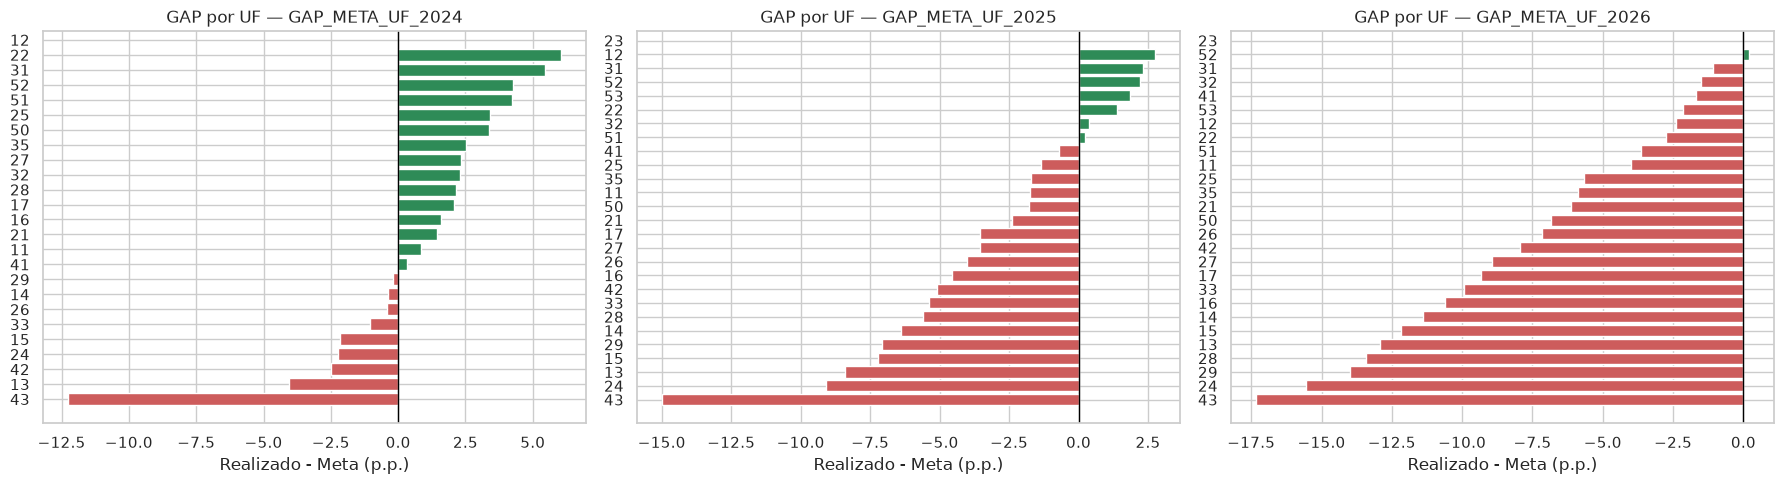

In [54]:
gap_cols_uf = [c for c in gap_uf.columns if c.startswith('GAP_')]

fig, axes = plt.subplots(1, len(gap_cols_uf), figsize=(6 * len(gap_cols_uf), 5))
if len(gap_cols_uf) == 1:
    axes = [axes]

for ax, col in zip(axes, gap_cols_uf):
    dados_ord = gap_uf.sort_values(col)
    cores = ['indianred' if v < 0 else 'seagreen' for v in dados_ord[col]]
    ax.barh(dados_ord['CO_UF'].astype(str), dados_ord[col], color=cores)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'GAP por UF — {col}')
    ax.set_xlabel('Realizado - Meta (p.p.)')

plt.tight_layout()
plt.show()


## 4.5 Cruzamento 3b — Classificação oficial de risco (Município e UF)

`fact_municipio` já traz uma **classificação oficial de risco de não atingir a meta**
(`CATEGORIA_RISCO_MUNICIPIO`, `CATEGORIA_RISCO_UF`) publicada pelo programa. É um insumo valioso,
mas exige cuidado: se o risco do ano Y foi calculado usando o resultado do próprio ano Y, usá-lo
como feature para prever o ano Y é leakage. A forma seguro de usar é como **feature de lag**
(risco classificado no ano anterior prevendo o resultado do ano atual) — mesma lógica já aplicada
na Seção 7.2.


% de municípios com risco oficial encontrado: 98.2%


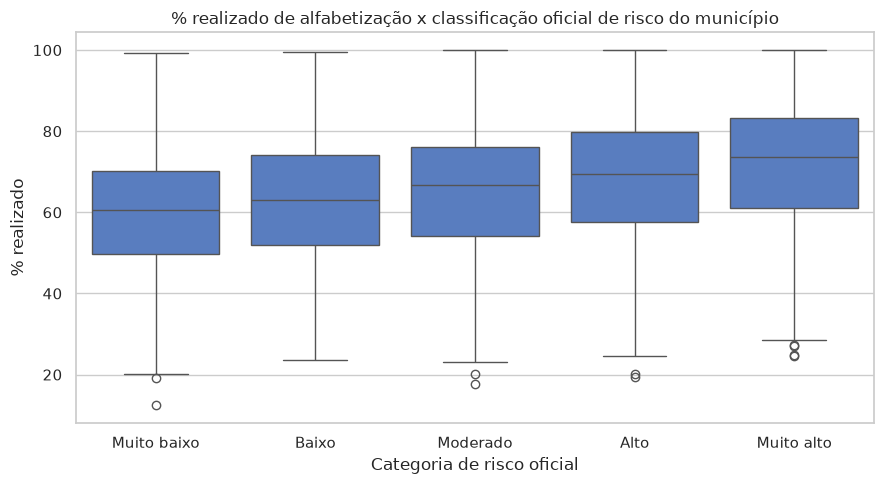

Se as categorias de risco separam bem o % realizado (boxplots com pouca sobreposição),
a classificação oficial é validada pelos nossos dados — e vira excelente feature (via lag).


In [55]:
fact_municipio_dedup = df_fact_municipio.drop_duplicates(subset=['CO_UF', 'CO_MUNICIPIO', 'NU_ANO_AVALIACAO'])

# Como gap_municipio (Seção 4) agrega alunos_validos por CO_UF+CO_MUNICIPIO sem quebrar por ano,
# usamos aqui a classificação de risco mais recente disponível por município (chave: CO_UF+CO_MUNICIPIO).
risco_municipio_mais_recente = (
    fact_municipio_dedup
    .sort_values('NU_ANO_AVALIACAO')
    .drop_duplicates(subset=['CO_UF', 'CO_MUNICIPIO'], keep='last')
    [['CO_UF', 'CO_MUNICIPIO', 'NU_ANO_AVALIACAO', 'CATEGORIA_RISCO_MUNICIPIO', 'CATEGORIA_RISCO_UF']]
)

if 'gap_municipio' in dir():
    comparacao_risco_municipio = gap_municipio.merge(
        risco_municipio_mais_recente,
        on=['CO_UF', 'CO_MUNICIPIO'],
        how='left',
    )

    taxa_match = comparacao_risco_municipio['CATEGORIA_RISCO_MUNICIPIO'].notna().mean()
    print(f"% de municípios com risco oficial encontrado: {taxa_match:.1%}")

    ordem_risco = ['Muito baixo', 'Baixo', 'Moderado', 'Alto', 'Muito alto']
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=comparacao_risco_municipio, x='CATEGORIA_RISCO_MUNICIPIO', y='pct_realizado',
        order=[o for o in ordem_risco if o in comparacao_risco_municipio['CATEGORIA_RISCO_MUNICIPIO'].unique()],
    )
    plt.title('% realizado de alfabetização x classificação oficial de risco do município')
    plt.ylabel('% realizado')
    plt.xlabel('Categoria de risco oficial')
    plt.show()

    print("Se as categorias de risco separam bem o % realizado (boxplots com pouca sobreposição),")
    print("a classificação oficial é validada pelos nossos dados — e vira excelente feature (via lag).")
else:
    print("Execute a Seção 4 (gap_municipio) antes desta célula.")


In [56]:
# Construindo a feature de LAG (recomendada): classificação de risco do ANO ANTERIOR,
# por CO_UF + CO_MUNICIPIO + ano (chave composta).
fact_municipio_lag = fact_municipio_dedup[[
    'CO_UF', 'CO_MUNICIPIO', 'NU_ANO_AVALIACAO', 'CATEGORIA_RISCO_MUNICIPIO', 'CATEGORIA_RISCO_UF'
]].copy()
fact_municipio_lag['NU_ANO_AVALIACAO'] = fact_municipio_lag['NU_ANO_AVALIACAO'] + 1
fact_municipio_lag = fact_municipio_lag.rename(columns={
    'CATEGORIA_RISCO_MUNICIPIO': 'CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR',
    'CATEGORIA_RISCO_UF': 'CATEGORIA_RISCO_UF_ANO_ANTERIOR',
})

print("Feature de lag construída (sem leakage): CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR")
display(fact_municipio_lag.head())
print("\n➡️ No pipeline de modelagem, fazer merge desta tabela em [CO_UF, CO_MUNICIPIO, NU_ANO_AVALIACAO].")


Feature de lag construída (sem leakage): CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR


,CO_UF,CO_MUNICIPIO,NU_ANO_AVALIACAO,CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR,CATEGORIA_RISCO_UF_ANO_ANTERIOR
0,11,1100015,2024,Baixo,Muito alto
1,11,1100023,2024,Muito baixo,Muito alto
2,11,1100031,2024,Muito alto,Muito alto
3,11,1100049,2024,Muito baixo,Muito alto
4,11,1100056,2024,Baixo,Muito alto



➡️ No pipeline de modelagem, fazer merge desta tabela em [CO_UF, CO_MUNICIPIO, NU_ANO_AVALIACAO].


## 4.6 Cruzamento 3c — Perfil de risco escolar agregado por MUNICÍPIO (`fact_escola`)

`fact_escola` traz `CATEGORIA_RISCO_ESCOLA`, `LOCALIZACAO` (urbana/rural) e `QT_MATRICULA_2ANO_EF`
por escola/ano — mas **não vamos juntar aluno-a-aluno com a escola**: `ID_ESCOLA` em `df_alunos` é
uma máscara/hash de privacidade e não corresponde ao código INEP real (`CO_ENTIDADE`) usado em
`fact_escola`. Tentar casar essas chaves geraria matches falsos ou uma taxa de match artificialmente
baixa.

A saída é **agregar `fact_escola` ao nível de município** (ele já traz `CO_UF`/`CO_MUNICIPIO`
nativamente) e usar esse perfil agregado como feature municipal — union pela mesma chave composta
`CO_UF + CO_MUNICIPIO` já usada na Seção 4.5.


In [68]:
perfil_escolar_municipio = (
    df_fact_escola
    .groupby(['CO_UF', 'CO_MUNICIPIO', 'NU_ANO_AVALIACAO'])
    .agg(
        qtd_escolas=('CO_ENTIDADE', 'nunique'),
        pct_escolas_risco_alto_muito_alto=('CATEGORIA_RISCO_ESCOLA',
            lambda s: s.isin(['Alto', 'Muito alto']).mean() * 100),
        pct_escolas_rural=('LOCALIZACAO', lambda s: (s == 'Rural').mean() * 100),
        matriculas_2ano_ef_total=('QT_MATRICULA_2ANO_EF', 'sum'),
    )
    .reset_index()
)

print(f"Perfil escolar agregado para {len(perfil_escolar_municipio):,} combinações município-ano.")
display(perfil_escolar_municipio.head())


KeyError: "Label(s) ['LOCALIZACAO'] do not exist"

In [67]:
# Usa o ano mais recente disponível por município (mesma lógica da Seção 4.5)
perfil_escolar_mais_recente = (
    perfil_escolar_municipio
    .sort_values('NU_ANO_AVALIACAO')
    .drop_duplicates(subset=['CO_UF', 'CO_MUNICIPIO'], keep='last')
)

if 'comparacao_risco_municipio' in dir():
    comparacao_risco_municipio = comparacao_risco_municipio.merge(
        perfil_escolar_mais_recente.drop(columns='NU_ANO_AVALIACAO'),
        on=['CO_UF', 'CO_MUNICIPIO'],
        how='left',
    )

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=comparacao_risco_municipio,
        x='pct_escolas_risco_alto_muito_alto', y='pct_realizado',
        scatter_kws={'alpha': 0.3},
    )
    plt.title('% realizado de alfabetização x % de escolas em risco alto/muito alto no município')
    plt.xlabel('% de escolas do município em risco alto/muito alto')
    plt.ylabel('% realizado de alfabetização')
    plt.show()

    corr = comparacao_risco_municipio[['pct_realizado', 'pct_escolas_risco_alto_muito_alto']].corr().iloc[0, 1]
    print(f"Correlação: {corr:.3f}")
else:
    print("Execute a célula anterior da Seção 4.5 (comparacao_risco_municipio) antes desta célula.")


NameError: name 'perfil_escolar_municipio' is not defined

## 5. Cruzamento 4 — Evolução temporal: Realizado × Meta

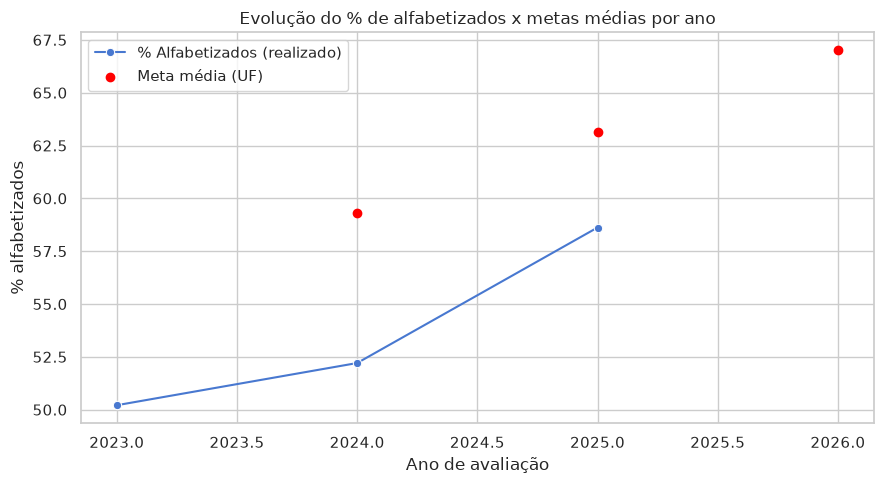

,NU_ANO_AVALIACAO,pct_alfabetizados,proficiencia_media
0,2023,50.212168,747.563828
1,2024,52.208803,749.042072
2,2025,58.621679,753.574276


In [59]:
evolucao = (
    alunos
    .groupby('NU_ANO_AVALIACAO')
    .agg(
        pct_alfabetizados=('IN_ALFABETIZADO', 'mean'),
        proficiencia_media=('VL_PROFICIENCIA_LP', 'mean'),
    )
    .reset_index()
)
evolucao['pct_alfabetizados'] *= 100

plt.figure(figsize=(9, 5))
sns.lineplot(data=evolucao, x='NU_ANO_AVALIACAO', y='pct_alfabetizados', marker='o', label='% Alfabetizados (realizado)')

for meta_col in [c for c in ['META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in alunos.columns]:
    ano_meta = int(meta_col.split('_')[-1])
    valor_meta = alunos[meta_col].mean()
    plt.scatter([ano_meta], [valor_meta], color='red', zorder=5,
                label='Meta média (UF)' if ano_meta == 2024 else None)

plt.title('Evolução do % de alfabetizados x metas médias por ano')
plt.ylabel('% alfabetizados')
plt.xlabel('Ano de avaliação')
plt.legend()
plt.show()

evolucao


## 6. Resumo dos cruzamentos (preencher após execução)

- **Contexto socioeconômico x alfabetização:** quais variáveis de `dim_contexto_socioeconomico_uf`
  mais se correlacionam (positiva/negativamente) com o % de alfabetizados?
- **Rede de ensino:** qual rede (municipal/estadual/privada/federal) tem melhor desempenho e maior gap
  em relação às demais?
- **Município x Meta:** quais municípios estão mais distantes da meta 2026? Há padrão geográfico (UF)?
- **UF x Meta:** quais UFs precisam de atenção prioritária?
- **Evolução temporal:** a trajetória realizada está convergindo para as metas estabelecidas?


---
# <font color="crimson">7. Auditoria de Data Leakage</font>

Requisito explícito do Tech Challenge Fase 3: *"tratamento de data leakage"*. Antes de definir
quais variáveis entram no modelo, precisamos identificar features que **vazam o rótulo**
(`IN_ALFABETIZADO`) direta ou indiretamente.

Fontes de leakage candidatas nesta base:
1. `VL_PROFICIENCIA_LP` — possivelmente `IN_ALFABETIZADO` é derivado de um corte nessa proficiência.
2. `PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO` / `_UF` — agregados que incluem o próprio aluno no cálculo.
3. `TX_RESPOSTA_BLOCO_*` / `TX_GABARITO_BLOCO_*` / `CO_BLOCO_*` — artefatos da prova, não features preditivas.


## 7.1 `VL_PROFICIENCIA_LP` deriva `IN_ALFABETIZADO`?

,count,mean,std,min,25%,50%,75%,max
IN_ALFABETIZADO,,,,,,,,
0,2033682.0,701.932007,32.675350,572.355896,681.494385,709.411499,729.250732,742.999939
1,3287584.0,780.219604,26.392244,743.000000,759.870895,775.481964,795.056046,904.382019


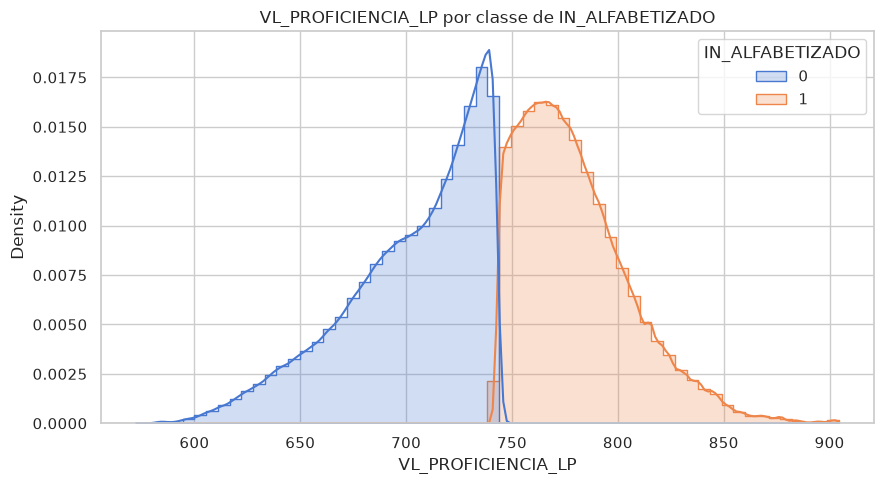

In [60]:
# Se houver um corte claro de proficiência que separa as classes, é leakage direto.
prof_por_classe = alunos_validos.groupby('IN_ALFABETIZADO')['VL_PROFICIENCIA_LP'].describe()
display(prof_por_classe)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=alunos_validos, x='VL_PROFICIENCIA_LP', hue='IN_ALFABETIZADO',
    kde=True, bins=60, element='step', stat='density', common_norm=False,
)
plt.title('VL_PROFICIENCIA_LP por classe de IN_ALFABETIZADO')
plt.show()

# Se as distribuições NÃO se sobrepõem (ex.: um corte nítido em algum valor de proficiência),
# isso confirma que IN_ALFABETIZADO foi construído a partir de VL_PROFICIENCIA_LP.
# Nesse caso, VL_PROFICIENCIA_LP e VL_PESO_ALUNO_LP NÃO devem entrar como features do modelo
# (ou só entram em uma análise à parte, nunca competindo como preditor "raso" do próprio corte).


## 7.2 Agregados de município/UF calculados *com* o próprio aluno (target leakage por agregação)

In [61]:
# Demonstração do problema: o percentual do município inclui a observação do próprio aluno.
# Solução 1 — Leave-one-out: recalcular o agregado excluindo o aluno da própria linha.
# Solução 2 — Lag: usar o agregado do ANO ANTERIOR (mais realista para previsão de risco futuro).

# Exemplo de leave-one-out (mais custoso, mas correto) para o indicador de alfabetização no município:
def leave_one_out_mean(df: pd.DataFrame, group_cols: list[str], target_col: str) -> pd.Series:
    soma_grupo = df.groupby(group_cols)[target_col].transform('sum')
    contagem_grupo = df.groupby(group_cols)[target_col].transform('count')
    # remove a própria observação da soma e da contagem
    return (soma_grupo - df[target_col]) / (contagem_grupo - 1).replace(0, np.nan)

if {'CO_UF', 'CO_MUNICIPIO', 'IN_ALFABETIZADO'}.issubset(alunos_validos.columns):
    amostra_loo = alunos_validos.sample(min(200_000, len(alunos_validos)), random_state=42).copy()
    amostra_loo['PC_ALFABETIZADO_MUNICIPIO_LOO'] = leave_one_out_mean(
        amostra_loo, ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'], 'IN_ALFABETIZADO'
    ) * 100

    comparacao = amostra_loo[[
        'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'PC_ALFABETIZADO_MUNICIPIO_LOO'
    ]].describe()
    display(comparacao)

    print("\nDiferença média (original - leave-one-out):",
          (amostra_loo['PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] -
           amostra_loo['PC_ALFABETIZADO_MUNICIPIO_LOO']).mean())


,PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO,PC_ALFABETIZADO_MUNICIPIO_LOO
count,199875.000000,197897.000000
mean,61.054749,53.907841
std,15.357730,20.269055
min,4.400000,0.000000
25%,51.400002,42.105263
50%,60.320000,52.000000
75%,70.980003,66.216216
max,100.000000,100.000000



Diferença média (original - leave-one-out): 7.035625553843738


In [62]:
# Alternativa recomendada para o pipeline de modelagem: usar o indicador do ANO ANTERIOR
# (lag), que é 100% livre de leakage e ainda mais útil no contexto de negócio
# ("prever risco futuro com base no histórico").

if 'NU_ANO_AVALIACAO' in alunos_validos.columns:
    indicador_muni_ano = (
        alunos_validos
        .groupby(['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'])['IN_ALFABETIZADO']
        .mean()
        .mul(100)
        .rename('PC_ALFABETIZADO_MUNICIPIO_ANO')
        .reset_index()
    )

    indicador_muni_ano_lag = indicador_muni_ano.copy()
    indicador_muni_ano_lag['NU_ANO_AVALIACAO'] = indicador_muni_ano_lag['NU_ANO_AVALIACAO'] + 1
    indicador_muni_ano_lag = indicador_muni_ano_lag.rename(
        columns={'PC_ALFABETIZADO_MUNICIPIO_ANO': 'PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR'}
    )

    print("Feature de lag construída (sem leakage): PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR")
    display(indicador_muni_ano_lag.head())
    print("\n➡️ No pipeline de modelagem, fazer merge desta tabela em `NU_ANO_AVALIACAO, CO_UF, CO_MUNICIPIO`")
    print("   no lugar de usar PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO diretamente.")


Feature de lag construída (sem leakage): PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR
0,2024,11,1100015.0,60.236220
1,2024,11,1100023.0,56.135195
2,2024,11,1100031.0,64.285714
3,2024,11,1100049.0,54.249738
4,2024,11,1100056.0,52.697095



➡️ No pipeline de modelagem, fazer merge desta tabela em `NU_ANO_AVALIACAO, CO_UF, CO_MUNICIPIO`
   no lugar de usar PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO diretamente.


## 7.3 Colunas de artefato da prova (não devem virar features)

In [63]:
cols_artefato_prova = [c for c in df_alunos.columns if c.startswith((
    'TX_RESPOSTA_BLOCO', 'TX_GABARITO_BLOCO', 'CO_BLOCO',
))]
print("Colunas identificadas como artefato da prova (excluir do modelo):")
for c in cols_artefato_prova:
    print(" -", c)


Colunas identificadas como artefato da prova (excluir do modelo):


## 7.4 Classificação final das colunas para o pipeline de modelagem

| Categoria | Colunas | Ação |
|---|---|---|
| 🔴 **Leakage direto** | `VL_PROFICIENCIA_LP`, `VL_PESO_ALUNO_LP` | Excluir do treino (só usar em análise descritiva/QA) — *confirmar com o item 7.1* |
| 🔴 **Leakage por agregação** | `PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO`, `PC_ALUNO_ALFABETIZADO_TOTAL_UF`, `VL_MEDIA_LP_TOTAL_MUNICIPIO`, `VL_MEDIA_LP_TOTAL_UF` | Substituir por versão **lag (ano anterior)** ou **leave-one-out** |
| 🔴 **Artefato de prova** | `TX_RESPOSTA_BLOCO_*`, `TX_GABARITO_BLOCO_*`, `CO_BLOCO_*` | Excluir do modelo |
| 🔴 **Chave não confiável** | `ID_ESCOLA` (aluno) | Não usar para juntar com `fact_escola` — é uma máscara/hash de privacidade, não corresponde a `CO_ENTIDADE` (INEP). `fact_escola` só é aproveitável agregado por **município** (ver Seção 4.6) |
| 🟠 **Risco oficial (zona cinzenta)** | `CATEGORIA_RISCO_ESCOLA` (agregado por município), `CATEGORIA_RISCO_MUNICIPIO`, `CATEGORIA_RISCO_UF` | Usar **apenas a versão de LAG (ano anterior)** — ver Seções 4.5/4.6. É um score já derivado de dados de alfabetização; usar o valor do mesmo ano é leakage |
| 🟡 **Filtro/derivação de target, não feature preditiva** | `IN_PRESENCA_LP`, `IN_PREENCHIMENTO_LP`, `SITUACAO_AVALIACAO` | Usadas para **redefinir o target** (`IN_ALFABETIZADO_FINAL`, Seção 2.1) — não entram como features |
| 🟢 **Features candidatas seguras** | `TP_DEPENDENCIA`/`DESC_DEPENDENCIA`, `CO_UF`/`SG_UF`, `CO_MUNICIPIO` (sempre em par com `CO_UF`), `TP_SERIE`, metas (`META_MUN_*`, `META_UF_*`), contexto socioeconômico UF (`POPULACAO_MIL`, `TAXA_ANALFABETISMO_PCT`, `RENDIMENTO_MEDIO_MENSAL_REAIS`, `RENDA_PERCAPITA_SBENEF_MEDIO`, `TAXA_FREQ_LIQUIDA_FUND_PCT`), perfil escolar agregado por município (`pct_escolas_risco_alto_muito_alto`, `pct_escolas_rural`, `qtd_escolas`, `matriculas_2ano_ef_total`) | Entram no pipeline, com encoding adequado à cardinalidade |

> **Chave de junção municipal:** sempre `CO_UF + CO_MUNICIPIO` (chave composta), nunca `CO_MUNICIPIO`
> isolado — evita colisões por truncamento/formatação divergente do código IBGE entre fontes.
>
> **Decisão de target (revisada na Seção 2.1):** alunos ausentes ou com preenchimento inválido
> deixaram de ser excluídos da base. Eles são tratados como **não alfabetizados**
> (`IN_ALFABETIZADO_FINAL = 0`), alinhado à metodologia oficial do indicador — essa é uma decisão
> de negócio, não uma correção técnica, e deve constar explicitamente no README.


---
# <font color="crimson">8. Análise orientada ao Target (`IN_ALFABETIZADO`)</font>


## 8.1 Balanceamento de classes

Distribuição do target (%):


IN_ALFABETIZADO
1    53.98
0    46.02
Name: proportion, dtype: float64

C:\Users\jack_\AppData\Local\Temp\ipykernel_19184\2810748842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=alunos_validos, x='IN_ALFABETIZADO', palette='Set2')


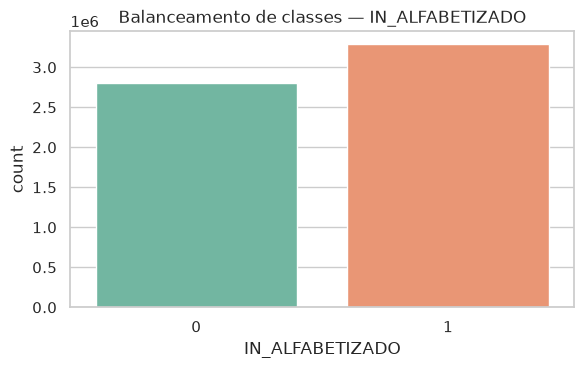

In [64]:
dist_target = alunos_validos['IN_ALFABETIZADO'].value_counts(normalize=True).mul(100).round(2)
print("Distribuição do target (%):")
display(dist_target)

plt.figure(figsize=(6, 4))
sns.countplot(data=alunos_validos, x='IN_ALFABETIZADO', palette='Set2')
plt.title('Balanceamento de classes — IN_ALFABETIZADO')
plt.show()

# Se o desbalanceamento for relevante (ex.: > 70/30), documentar aqui a estratégia:
# - Métricas: priorizar F1 / recall / PR-AUC (não accuracy)
# - class_weight='balanced' no modelo, e/ou técnicas de reamostragem (SMOTE) só no TREINO


## 8.2 Associação de cada feature candidata com o target

In [65]:
from scipy import stats

def point_biserial_com_target(df: pd.DataFrame, col_numerica: str, col_target: str) -> tuple[float, float]:
    dados = df[[col_numerica, col_target]].dropna()
    if dados[col_target].nunique() < 2:
        return np.nan, np.nan
    r, p = stats.pointbiserialr(dados[col_target], dados[col_numerica])
    return r, p


cols_numericas_seguras = [c for c in [
    'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026',
    'META_UF_2024', 'META_UF_2025', 'META_UF_2026',
] if c in alunos_validos.columns]

resultados_correlacao = []
for col in cols_numericas_seguras:
    r, p = point_biserial_com_target(alunos_validos, col, 'IN_ALFABETIZADO')
    resultados_correlacao.append({'feature': col, 'correlacao_point_biserial': r, 'p_valor': p})

pd.DataFrame(resultados_correlacao).sort_values('correlacao_point_biserial', key=abs, ascending=False)


,feature,correlacao_point_biserial,p_valor
1,META_MUN_2025,0.224363,0.0
0,META_MUN_2024,0.223892,0.0
2,META_MUN_2026,0.223886,0.0
5,META_UF_2026,0.135343,0.0
3,META_UF_2024,0.135268,0.0
4,META_UF_2025,0.134169,0.0


In [66]:
def cramers_v(col_categorica: pd.Series, col_target: pd.Series) -> float:
    """Associação entre duas variáveis categóricas (0 = nenhuma, 1 = associação perfeita)."""
    tabela = pd.crosstab(col_categorica, col_target)
    chi2 = stats.chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    r, k = tabela.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1) or 1))


cols_categoricas_seguras = [c for c in [
    'TP_DEPENDENCIA', 'SG_UF', 'TP_SERIE',
] if c in alunos_validos.columns]

resultados_cramers_v = []
for col in cols_categoricas_seguras:
    v = cramers_v(alunos_validos[col].astype(str), alunos_validos['IN_ALFABETIZADO'])
    resultados_cramers_v.append({'feature': col, 'cramers_v': v})

pd.DataFrame(resultados_cramers_v).sort_values('cramers_v', ascending=False)


,feature,cramers_v
0,TP_DEPENDENCIA,0.004791


## 8.3 Cardinalidade das variáveis categóricas (define a estratégia de encoding)

In [69]:
cols_categoricas_todas = alunos_validos.select_dtypes(include=['object', 'category']).columns.tolist()

cardinalidade = pd.DataFrame({
    'coluna': cols_categoricas_todas,
    'n_categorias': [alunos_validos[c].nunique() for c in cols_categoricas_todas],
}).sort_values('n_categorias', ascending=False)

cardinalidade['estrategia_sugerida'] = cardinalidade['n_categorias'].apply(
    lambda n: 'One-Hot Encoding' if n <= 15
    else ('Target/Frequency Encoding (com CV para evitar leakage)' if n <= 1000
          else 'Frequency Encoding ou agrupar em categorias maiores (ex.: região)')
)

cardinalidade


C:\Users\jack_\AppData\Local\Temp\ipykernel_19184\3107050063.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas_todas = alunos_validos.select_dtypes(include=['object', 'category']).columns.tolist()


,coluna,n_categorias,estrategia_sugerida
0,CO_UF,27,Target/Frequency Encoding (com CV para evitar ...
1,TP_DEPENDENCIA,3,One-Hot Encoding
2,SITUACAO_AVALIACAO,3,One-Hot Encoding


---
# <font color="crimson">9. Hipóteses Analíticas</font>

O desafio pede explicitamente que a EDA *"apoie diretamente as decisões de modelagem"* através
de hipóteses formuladas e testadas. Abaixo, três hipóteses de negócio centrais.

- **H1:** A rede municipal apresenta taxa de alfabetização menor que a rede privada.
- **H2:** UFs com pior contexto socioeconômico têm maior risco de não-alfabetização.
- **H3:** Municípios mais distantes da meta em anos anteriores tendem a continuar distantes
  (persistência de risco ano a ano) — justifica o uso de features de lag.


### H1 — Rede municipal x rede privada

In [70]:
if 'DESC_DEPENDENCIA' in alunos_validos.columns:
    taxa_por_rede = (
        alunos_validos.groupby('DESC_DEPENDENCIA')['IN_ALFABETIZADO']
        .mean().mul(100).sort_values(ascending=False)
    )
    display(taxa_por_rede)

    grupos = [g['IN_ALFABETIZADO'].values for _, g in alunos_validos.groupby('DESC_DEPENDENCIA')]
    if len(grupos) >= 2:
        stat, p = stats.f_oneway(*grupos)
        print(f"\nANOVA entre redes — estatística: {stat:.2f} | p-valor: {p:.2e}")
        print("=> Diferença estatisticamente significativa entre redes." if p < 0.05
              else "=> Sem diferença estatisticamente significativa entre redes.")


### H2 — Contexto socioeconômico x risco de não-alfabetização

Correlação de cada variável de contexto com % de alfabetizados (UF):



proficiencia_media               0.947107
ANO                              0.366282
NU_ANO_AVALIACAO                 0.366282
CO_UF                            0.186231
COD_UF                           0.186231
qtd_alunos                       0.137363
RENDA_PERCAPITA_SBENEF_MEDIO     0.130957
POPULACAO_MIL                    0.112888
RENDIMENTO_MEDIO_MENSAL_REAIS    0.102649
TAXA_FREQ_LIQUIDA_FUND_PCT      -0.096171
TAXA_ANALFABETISMO_PCT          -0.055708
Name: pct_alfabetizados, dtype: float64

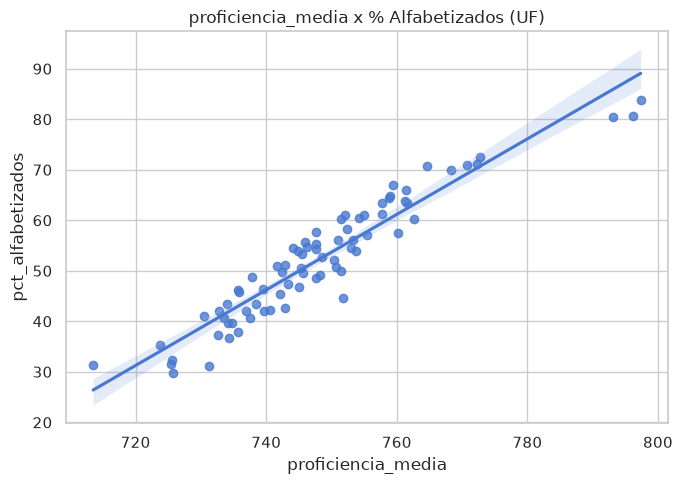

In [71]:
# Reaproveita `cruzamento_uf_contexto` construído na Seção 2.
if 'cruzamento_uf_contexto' in dir() and 'pct_alfabetizados' in cruzamento_uf_contexto.columns:
    top_correlacoes = (
        cruzamento_uf_contexto.select_dtypes(include=[np.number])
        .corr(numeric_only=True)['pct_alfabetizados']
        .drop('pct_alfabetizados', errors='ignore')
        .dropna()
        .sort_values(key=abs, ascending=False)
    )
    print("Correlação de cada variável de contexto com % de alfabetizados (UF):\n")
    display(top_correlacoes)

    if len(top_correlacoes) > 0:
        var_mais_forte = top_correlacoes.index[0]
        plt.figure(figsize=(7, 5))
        sns.regplot(data=cruzamento_uf_contexto, x=var_mais_forte, y='pct_alfabetizados')
        plt.title(f'{var_mais_forte} x % Alfabetizados (UF)')
        plt.show()
else:
    print("Execute a Seção 2 (Cruzamento contexto socioeconômico) antes desta célula.")


### H3 — Persistência de risco entre anos (justifica features de lag)

Correlação entre indicador do ano atual e do ano anterior (nível município): 0.678


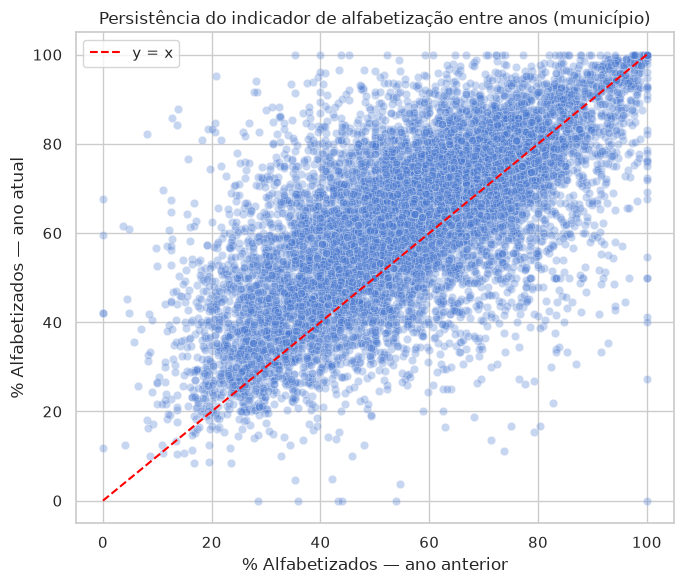


Correlação alta confirma H3: histórico do município é preditor forte do desempenho futuro, justificando o uso de PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR como feature.


In [72]:
if 'indicador_muni_ano' in dir():
    persistencia = indicador_muni_ano.sort_values(['CO_UF', 'CO_MUNICIPIO', 'NU_ANO_AVALIACAO'])
    persistencia['PC_ANO_ANTERIOR'] = (
        persistencia.groupby(['CO_UF', 'CO_MUNICIPIO'])['PC_ALFABETIZADO_MUNICIPIO_ANO'].shift(1)
    )
    persistencia_valida = persistencia.dropna(subset=['PC_ANO_ANTERIOR'])

    if len(persistencia_valida) > 30:
        corr_persistencia = persistencia_valida['PC_ALFABETIZADO_MUNICIPIO_ANO'].corr(
            persistencia_valida['PC_ANO_ANTERIOR']
        )
        print(f"Correlação entre indicador do ano atual e do ano anterior (nível município): "
              f"{corr_persistencia:.3f}")

        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=persistencia_valida, x='PC_ANO_ANTERIOR', y='PC_ALFABETIZADO_MUNICIPIO_ANO', alpha=0.3)
        plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='y = x')
        plt.title('Persistência do indicador de alfabetização entre anos (município)')
        plt.xlabel('% Alfabetizados — ano anterior')
        plt.ylabel('% Alfabetizados — ano atual')
        plt.legend()
        plt.show()

        print("\nCorrelação alta confirma H3: histórico do município é preditor forte do desempenho "
              "futuro, justificando o uso de PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR como feature.")
    else:
        print("Poucos pares ano-a-ano disponíveis para validar H3 (verifique quantos anos existem na base).")
else:
    print("Execute a Seção 7.2 antes desta célula (cria `indicador_muni_ano`).")


---
# <font color="crimson">10. Padrões Regionais — "Quais regiões possuem padrões semelhantes?"</font>

Agrupamento (K-Means) das UFs a partir de indicadores educacionais + contexto socioeconômico,
para identificar clusters de regiões com perfis semelhantes de risco educacional.


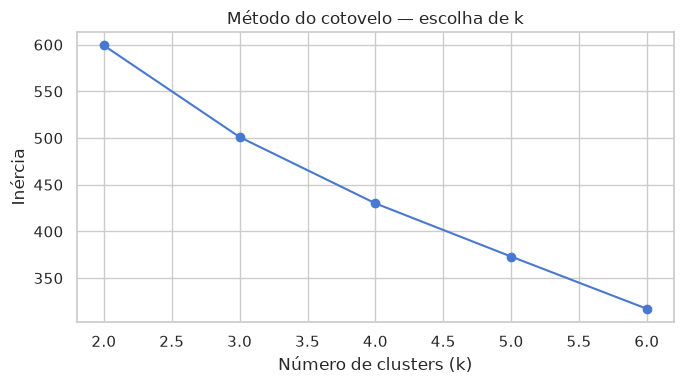

In [73]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

if 'cruzamento_uf_contexto' in dir():
    base_cluster = cruzamento_uf_contexto.select_dtypes(include=[np.number]).drop(
        columns=['CO_UF'], errors='ignore'
    ).dropna(axis=1, how='all')
    base_cluster = base_cluster.dropna()

    if len(base_cluster) >= 4 and base_cluster.shape[1] >= 2:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(base_cluster)

        # Escolha do número de clusters via método do cotovelo (rápido, k de 2 a 6)
        inercias = []
        k_range = range(2, min(7, len(base_cluster)))
        for k in k_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(X_scaled)
            inercias.append(km.inertia_)

        plt.figure(figsize=(7, 4))
        plt.plot(list(k_range), inercias, marker='o')
        plt.title('Método do cotovelo — escolha de k')
        plt.xlabel('Número de clusters (k)')
        plt.ylabel('Inércia')
        plt.show()
    else:
        print("Poucos dados/variáveis numéricas para clustering. Confira o merge com o contexto socioeconômico.")
else:
    print("Execute a Seção 2 antes desta célula.")


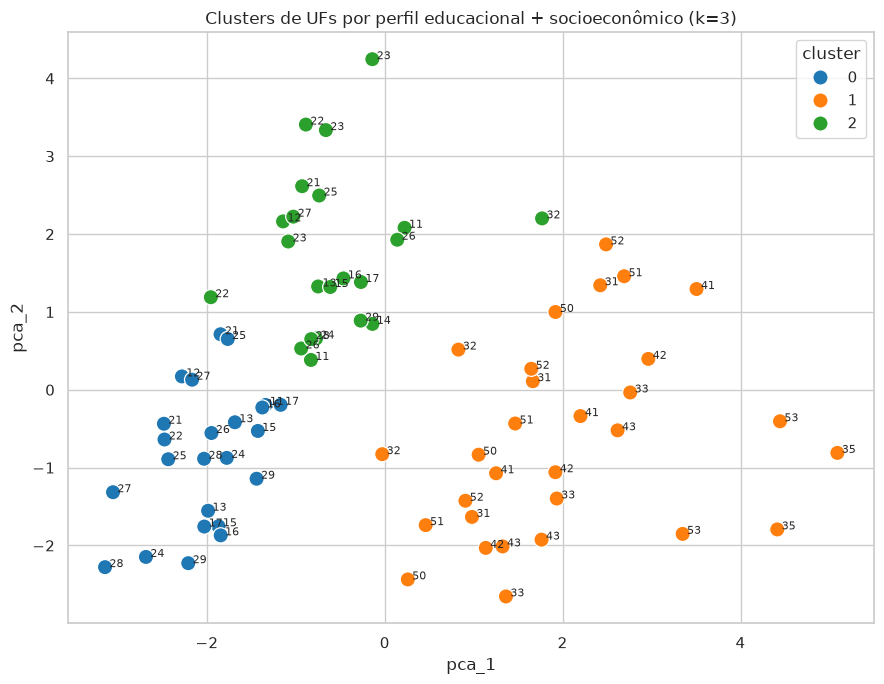

,pct_alfabetizados,proficiencia_media
cluster,,
0,41.754525,736.898132
1,55.463722,750.892700
2,59.705192,756.940430


In [74]:
# Ajuste K_ESCOLHIDO com base no cotovelo observado acima
K_ESCOLHIDO = 3

if 'X_scaled' in dir():
    kmeans_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
    clusters = kmeans_final.fit_predict(X_scaled)

    cruzamento_uf_contexto_clusters = cruzamento_uf_contexto.loc[base_cluster.index].copy()
    cruzamento_uf_contexto_clusters['cluster'] = clusters

    pca = PCA(n_components=2, random_state=42)
    coords_pca = pca.fit_transform(X_scaled)
    cruzamento_uf_contexto_clusters['pca_1'] = coords_pca[:, 0]
    cruzamento_uf_contexto_clusters['pca_2'] = coords_pca[:, 1]

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=cruzamento_uf_contexto_clusters, x='pca_1', y='pca_2',
        hue='cluster', palette='tab10', s=120,
    )
    for _, row in cruzamento_uf_contexto_clusters.iterrows():
        plt.text(row['pca_1'] + 0.05, row['pca_2'], str(row.get('CO_UF', '')), fontsize=8)
    plt.title(f'Clusters de UFs por perfil educacional + socioeconômico (k={K_ESCOLHIDO})')
    plt.show()

    display(
        cruzamento_uf_contexto_clusters
        .groupby('cluster')[['pct_alfabetizados', 'proficiencia_media']]
        .mean()
    )


---
# <font color="crimson">11. Preparação para a etapa de Modelagem</font>

Encerrando a EDA com as decisões que alimentam diretamente o pipeline de Machine Learning
(próximo notebook/script em `src/preprocessing`).


## 11.1 Estratégia de split — temporal, não aleatório

In [75]:
anos_disponiveis = sorted(alunos_validos['NU_ANO_AVALIACAO'].dropna().unique())
print("Anos disponíveis na base:", anos_disponiveis)

if len(anos_disponiveis) >= 2:
    ano_teste = anos_disponiveis[-1]
    anos_treino = anos_disponiveis[:-1]
    print(f"\nEstratégia recomendada: treino em {anos_treino} | teste em {ano_teste}")
    print("Justificativa: evita leakage temporal e simula o cenário real de uso do modelo "
          "(prever o ano seguinte com base no histórico).")
else:
    print("Apenas um ano disponível — usar split aleatório estratificado por classe (train_test_split "
          "com stratify=y), sem esquecer de manter alunos do mesmo município no mesmo split quando possível.")


Anos disponíveis na base: [np.int16(2023), np.int16(2024), np.int16(2025)]

Estratégia recomendada: treino em [np.int16(2023), np.int16(2024)] | teste em 2025
Justificativa: evita leakage temporal e simula o cenário real de uso do modelo (prever o ano seguinte com base no histórico).


## 11.2 Lista final de features recomendadas para o pipeline

In [ ]:
features_recomendadas = {
    'territoriais': [c for c in ['CO_UF', 'SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO'] if c in alunos_validos.columns],
    'educacionais': [c for c in ['TP_DEPENDENCIA', 'DESC_DEPENDENCIA', 'TP_SERIE', 'DESC_SERIE'] if c in alunos_validos.columns],
    'metas': [c for c in [
        'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026',
        'META_UF_2024', 'META_UF_2025', 'META_UF_2026',
    ] if c in alunos_validos.columns],
    'historico_sem_leakage (lag, ver Seção 7.2)': ['PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR'],
    'risco_oficial_lag (ver Seção 4.5, chave CO_UF+CO_MUNICIPIO)': [
        'CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR', 'CATEGORIA_RISCO_UF_ANO_ANTERIOR',
    ],
    'contexto_socioeconomico_uf (ver Seção 1/2, dim_contexto_socioeconomico_uf)': [
        'POPULACAO_MIL', 'TAXA_ANALFABETISMO_PCT', 'RENDIMENTO_MEDIO_MENSAL_REAIS',
        'RENDA_PERCAPITA_SBENEF_MEDIO', 'TAXA_FREQ_LIQUIDA_FUND_PCT',
    ],
    'perfil_escolar_agregado_por_municipio (ver Seção 4.6, fact_escola agregado — NÃO usar ID_ESCOLA)': [
        'pct_escolas_risco_alto_muito_alto', 'pct_escolas_rural', 'qtd_escolas', 'matriculas_2ano_ef_total',
    ],
    'EXCLUIR (leakage ou chave não confiável)': [
        'VL_PROFICIENCIA_LP', 'VL_PESO_ALUNO_LP',
        'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
        'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF',
        'TX_RESPOSTA_BLOCO_*', 'TX_GABARITO_BLOCO_*', 'CO_BLOCO_*',
        'ID_ESCOLA (máscara de privacidade, não casa com CO_ENTIDADE)',
        'CATEGORIA_RISCO_ESCOLA/MUNICIPIO/UF do MESMO ano (só a versão lag é segura)',
    ],
    'target': ['IN_ALFABETIZADO (= IN_ALFABETIZADO_FINAL, ver decisão da Seção 2.1)'],
}

for categoria, cols in features_recomendadas.items():
    print(f"\n{categoria}:")
    for c in cols:
        print("  -", c)



territoriais:
  - CO_UF
  - CO_MUNICIPIO

educacionais:
  - TP_DEPENDENCIA

metas:
  - META_MUN_2024
  - META_MUN_2025
  - META_MUN_2026
  - META_UF_2024
  - META_UF_2025
  - META_UF_2026

historico_sem_leakage (lag, ver Seção 7.2):
  - PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR

risco_oficial_lag (ver Seção 4.5, chave CO_UF+CO_MUNICIPIO):
  - CATEGORIA_RISCO_MUNICIPIO_ANO_ANTERIOR
  - CATEGORIA_RISCO_UF_ANO_ANTERIOR

contexto_socioeconomico_uf (ver Seção 1/2, dim_contexto_socioeconomico_uf):
  - POPULACAO_MIL
  - TAXA_ANALFABETISMO_PCT
  - RENDIMENTO_MEDIO_MENSAL_REAIS
  - RENDA_PERCAPITA_SBENEF_MEDIO
  - TAXA_FREQ_LIQUIDA_FUND_PCT

perfil_escolar_agregado_por_municipio (ver Seção 4.6, fact_escola agregado — NÃO usar ID_ESCOLA):
  - pct_escolas_risco_alto_muito_alto
  - pct_escolas_rural
  - qtd_escolas
  - matriculas_2ano_ef_total

EXCLUIR (leakage ou chave não confiável):
  - VL_PROFICIENCIA_LP
  - VL_PESO_ALUNO_LP
  - PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO
  - PC_ALUNO_ALFABETIZADO_TOT

## 11.3 Salvando a base tratada para a etapa de modelagem

In [ ]:
import os

os.makedirs('../data/processed', exist_ok=True)

caminho_saida = '../data/processed/alunos_alfabetizacao_tratado.parquet'
alunos_validos.to_parquet(caminho_saida, index=False)

print(f"Base salva em: {caminho_saida}")
print(f"Shape final: {alunos_validos.shape}")


## 11.4 Resumo executivo da EDA para a modelagem

- **Leakage identificado e tratado:** proficiência/peso e agregados de município/UF calculados
  com o próprio aluno — substituídos por versão **lag** (ano anterior) ou removidos.
- **Balanceamento do target:** ver Seção 8.1 — define métrica de avaliação (accuracy vs F1/PR-AUC)
  e necessidade de `class_weight`/reamostragem.
- **Features com maior associação ao target:** ver rankings das Seções 8.2 e 9 (H1/H2).
- **Persistência temporal confirmada (H3):** justifica manter `PC_ALFABETIZADO_MUNICIPIO_ANO_ANTERIOR`
  como feature central e usar **split temporal** (Seção 11.1) em vez de aleatório.
- **Clusters regionais (Seção 10):** grupos de UFs com perfil semelhante — insumo direto para a
  pergunta de negócio *"quais regiões possuem padrões semelhantes?"* e para segmentar políticas públicas.
- **Cardinalidade mapeada (Seção 8.3):** define a estratégia de encoding por coluna categórica.
